In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [25]:
df = pd.read_csv('cardekho_data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [27]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [28]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [29]:
df['Car_Name'].value_counts()

Car_Name
city                        26
corolla altis               16
verna                       14
fortuner                    11
brio                        10
                            ..
Honda CB Trigger             1
Yamaha FZ S                  1
Bajaj Pulsar 135 LS          1
Activa 4g                    1
Bajaj Avenger Street 220     1
Name: count, Length: 98, dtype: int64

In [30]:
df['Car_Name'].unique()

array(['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza',
       's cross', 'alto 800', 'ertiga', 'dzire', 'alto k10', 'ignis',
       '800', 'baleno', 'omni', 'fortuner', 'innova', 'corolla altis',
       'etios cross', 'etios g', 'etios liva', 'corolla', 'etios gd',
       'camry', 'land cruiser', 'Royal Enfield Thunder 500',
       'UM Renegade Mojave', 'KTM RC200', 'Bajaj Dominar 400',
       'Royal Enfield Classic 350', 'KTM RC390', 'Hyosung GT250R',
       'Royal Enfield Thunder 350', 'KTM 390 Duke ',
       'Mahindra Mojo XT300', 'Bajaj Pulsar RS200',
       'Royal Enfield Bullet 350', 'Royal Enfield Classic 500',
       'Bajaj Avenger 220', 'Bajaj Avenger 150', 'Honda CB Hornet 160R',
       'Yamaha FZ S V 2.0', 'Yamaha FZ 16', 'TVS Apache RTR 160',
       'Bajaj Pulsar 150', 'Honda CBR 150', 'Hero Extreme',
       'Bajaj Avenger 220 dtsi', 'Bajaj Avenger 150 street',
       'Yamaha FZ  v 2.0', 'Bajaj Pulsar  NS 200', 'Bajaj Pulsar 220 F',
       'TVS Apache RTR 180', 

In [31]:

label_cols = ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']
for col in label_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,90,2014,3.35,5.59,27000,2,0,1,0
1,93,2013,4.75,9.54,43000,1,0,1,0
2,68,2017,7.25,9.85,6900,2,0,1,0
3,96,2011,2.85,4.15,5200,2,0,1,0
4,92,2014,4.60,6.87,42450,1,0,1,0


In [32]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(240, 8) (61, 8) (240,) (61,)


In [33]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240 entries, 184 to 102
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       240 non-null    int64  
 1   Year           240 non-null    int64  
 2   Present_Price  240 non-null    float64
 3   Kms_Driven     240 non-null    int64  
 4   Fuel_Type      240 non-null    int64  
 5   Seller_Type    240 non-null    int64  
 6   Transmission   240 non-null    int64  
 7   Owner          240 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 16.9 KB


In [34]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_dt)

In [35]:
print(f"Mean Squared Error of Decision Tree: {mse}")

Mean Squared Error of Decision Tree: 1.725045854906544


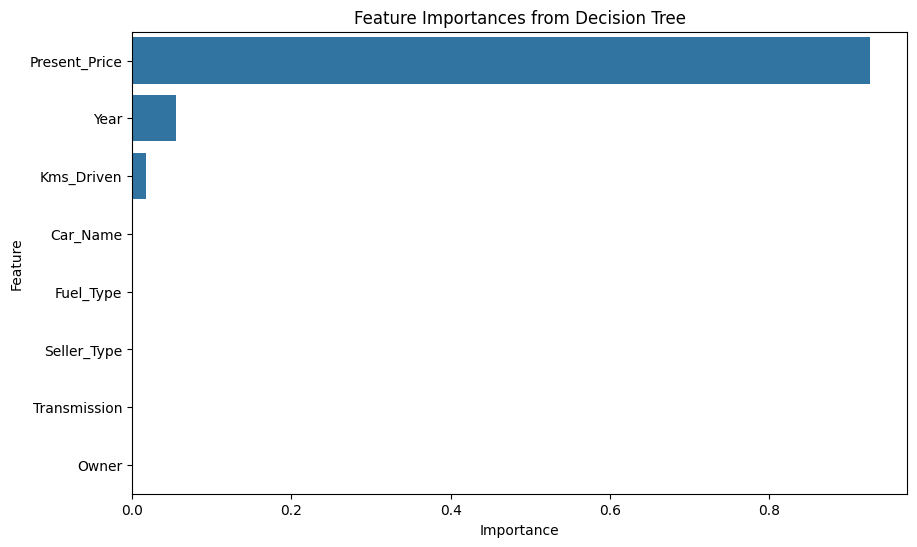

In [36]:
dt_importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=dt_importances.values, y=dt_importances.index)
plt.title('Feature Importances from Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

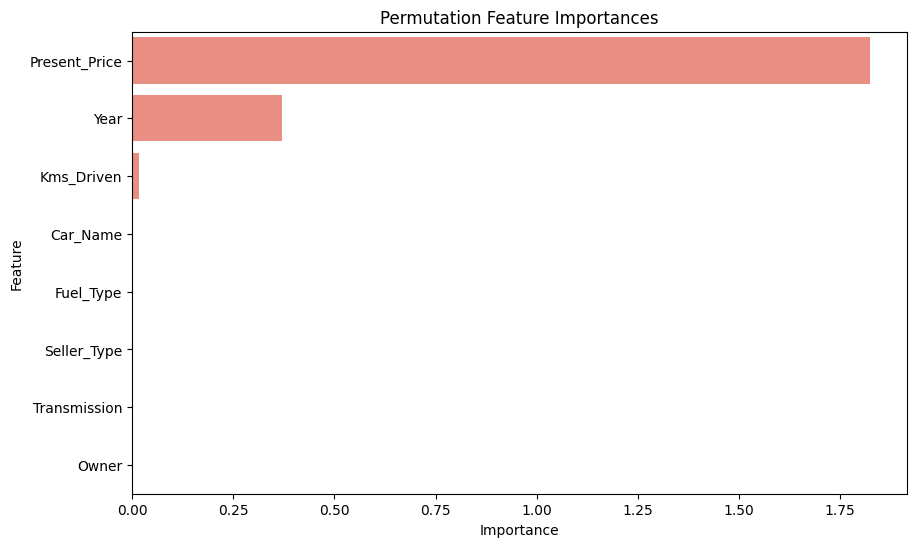

In [37]:
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(dt_model, X_test, y_test, n_repeats=10, random_state=42)
perm_importance = pd.Series(perm_importance.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=perm_importance.values, y=perm_importance.index, color='salmon')
plt.title('Permutation Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

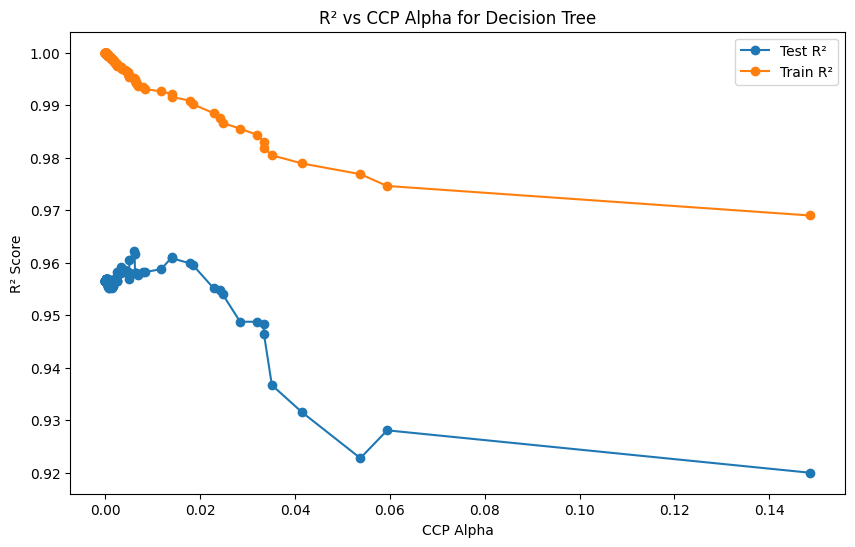

In [38]:
dt_model_full = DecisionTreeRegressor(random_state=10)
path = dt_model_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:180]

r2_test_list = []
r2_train_list = []

for a in ccp_alphas:
    dt_temp = DecisionTreeRegressor(random_state=10, ccp_alpha=a)
    dt_temp.fit(X_train, y_train)
    r2_test = r2_score(y_test, dt_temp.predict(X_test))
    r2_train = r2_score(y_train, dt_temp.predict(X_train))

    r2_test_list.append(r2_test)
    r2_train_list.append(r2_train)

plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, r2_test_list, marker='o', label='Test R²')
plt.plot(ccp_alphas, r2_train_list, marker='o', label='Train R²')
plt.xlabel('CCP Alpha')
plt.ylabel('R² Score')
plt.title('R² vs CCP Alpha for Decision Tree')
plt.legend()

In [39]:
best_alpha = ccp_alphas[r2_test_list.index(max(r2_test_list))]
print(f"Best CCP Alpha: {best_alpha}")
best_dt_model = DecisionTreeRegressor(random_state=10, ccp_alpha=best_alpha)
best_dt_model.fit(X_train, y_train)
y_pred_best_dt = best_dt_model.predict(X_test)
best_mse = mean_squared_error(y_test, y_pred_best_dt)
print(f"Mean Squared Error of Best Decision Tree: {best_mse}")
best_r2 = r2_score(y_test, y_pred_best_dt)
print(f"R² Score of Best Decision Tree: {best_r2}")

Best CCP Alpha: 0.00601666666666644
Mean Squared Error of Best Decision Tree: 0.8703018407250137
R² Score of Best Decision Tree: 0.9622192421486664


In [40]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=10, oob_score=True)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_r2_score = r2_score(y_test, y_pred_rf)
print(f"R² Score of Random Forest: {rf_r2_score}")
oob_score = rf_model.oob_score_
print(f"OOB Score of Random Forest: {oob_score}")

R² Score of Random Forest: 0.9638448756081316
OOB Score of Random Forest: 0.8853621044357483


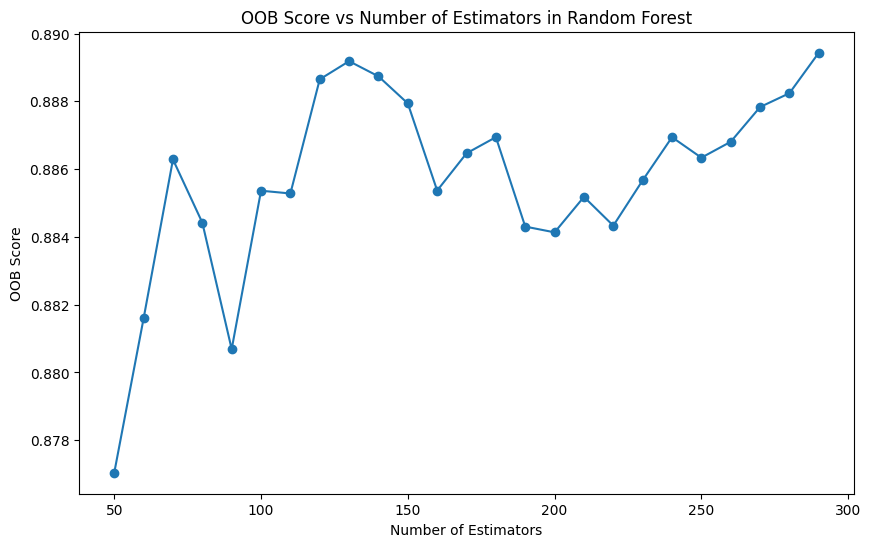

In [41]:
estimator_range = range(50, 300, 10)
oob_scores = []

for n in estimator_range:
    rf_temp = RandomForestRegressor(n_estimators=n, random_state=10, oob_score=True)
    rf_temp.fit(X_train, y_train)
    oob_scores.append(rf_temp.oob_score_)

plt.figure(figsize=(10, 6))
plt.plot(estimator_range, oob_scores, marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('OOB Score')
plt.title('OOB Score vs Number of Estimators in Random Forest')
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


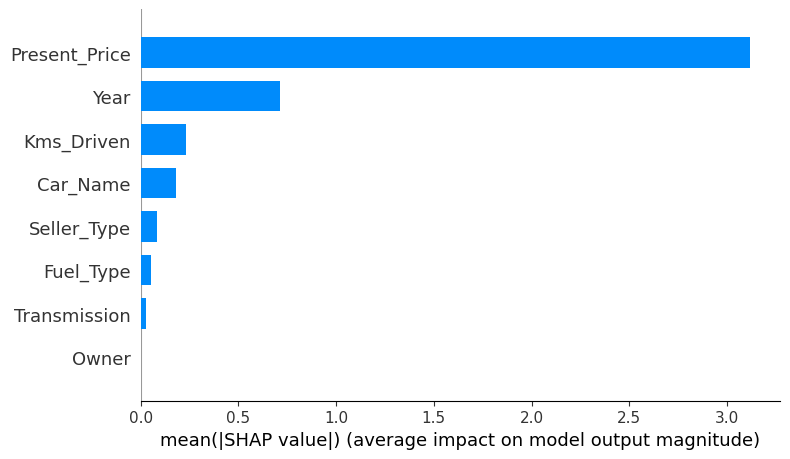

In [42]:
import shap

shape_explainer = shap.TreeExplainer(rf_model)
shap_values = shape_explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar')

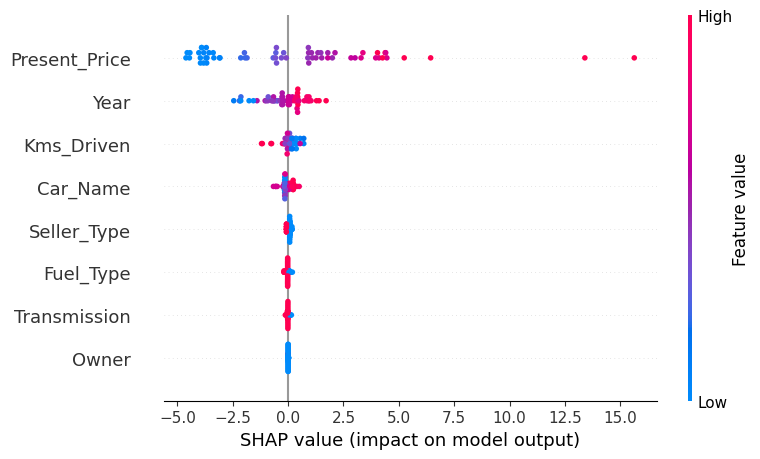

In [43]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test)
plt.show()

In [44]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=10, n_estimators=130)

df_iso = df.copy()
X_iso = df_iso.drop('Selling_Price', axis=1)
y_iso = df_iso['Selling_Price']

df_iso['anomaly'] = iso_forest.fit_predict(X_iso)
df_iso['anomaly-score'] = iso_forest.decision_function(X_iso)

n_anomalies = (df_iso['anomaly'] == -1).sum()
print(f"Number of anomalies detected: {n_anomalies}")

Number of anomalies detected: 15


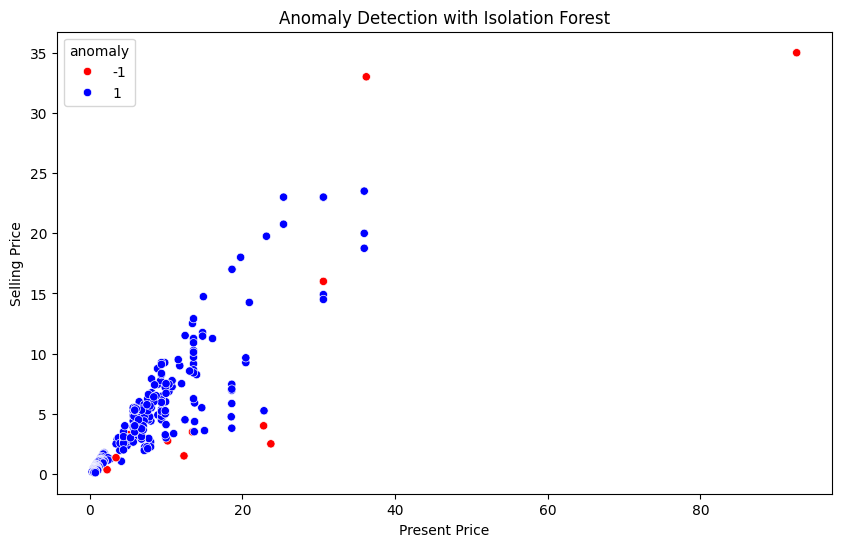

In [45]:
X_present_price = df_iso['Present_Price']
Y_selling_price = df_iso['Selling_Price']
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_present_price, y=Y_selling_price, hue=df_iso['anomaly'], palette={1: 'blue', -1: 'red'})
plt.title('Anomaly Detection with Isolation Forest')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.show()

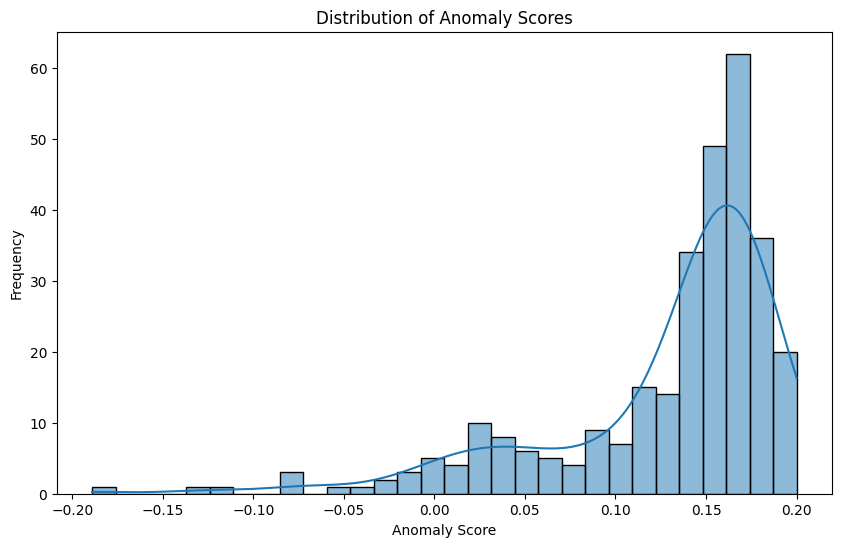

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(df_iso['anomaly-score'], bins=30, kde=True)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.show()